In [1]:
import sys, os
sys.path.append(os.path.abspath('../../..'))

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import equinox as eqx
import galsim as gs
from galsim.hsm import FindAdaptiveMom

import warnings
warnings.filterwarnings('ignore')

from src.shearest.data_gen_utils import draw_AE_HST_profiles, draw_spergel_profile
from src.shearest.psf_utils import compute_radio_uv_mask
from pshear.utils import load_galaxy_autoencoder

In [2]:
Ngal = 10
Npx = 128
pixel_scale     = 0.15            # radio (used to build uv mask)
pixel_scale_hst = 0.03            # HST stamp pixel scale
pixel_scale_vae = 0.03            # AE rendering pixel scale
fov_size = Npx * pixel_scale / 3600  # degrees

mag_cut = 24.0
sample = '25.2'
seed = 42
g1_true, g2_true = 0.0, 0.0   # no shear — compare unsheared shapes

cosmos_path = '/Users/ec270266/Documents/Phd/Argos/Datasets/COSMOS_25.2_training_sample'
vae_path = '/Users/ec270266/Documents/Phd/Argos/repos/probabilistic-shear/models/pretrained_benjamin'
vae_epoch = 920

In [3]:
# UV mask via the same call signature as the main script
uv_pos, mask, radio_psf = compute_radio_uv_mask(
    n_antenna=50, E_lim=50e3, N_lim=50e3,
    Npx=Npx, fov_size=fov_size,
    track_time=8, t_0=-4, n_times=96,
    f=1.4e9, df=1e8, n_freqs=1,
    lat=-30 * np.pi / 180, dec=-30 * np.pi / 180,
    antenna='file', antenna_file='../../../data/SKA-Mid.txt',
    uv_mask_weighting='binary',
)
print(f'UV mask cells nonzero: {len(uv_pos[0])} / {Npx*Npx}')

UV mask cells nonzero: 7879 / 16384


In [4]:
# Load AE in inference mode
ae = load_galaxy_autoencoder(Path(vae_path), epoch=vae_epoch)
ae = eqx.nn.inference_mode(ae, True)
print(f'AE loaded from {vae_path} epoch {vae_epoch}')

AE loaded from /Users/ec270266/Documents/Phd/Argos/repos/probabilistic-shear/models/pretrained_benjamin epoch 920


In [5]:
vis_ae, indices_ae, z_enc = draw_AE_HST_profiles(
    Ngal=Ngal, dataset_dir=cosmos_path, ae=ae,
    g1=g1_true, g2=g2_true, uv_pos=uv_pos, Npx=Npx,
    pixel_scale_hst=pixel_scale_hst, pixel_scale_vae=pixel_scale_vae,
    sample=sample, seed=seed, mag_cut=mag_cut,
)
vis_ae = np.array(vis_ae)
print(f'vis_ae shape: {vis_ae.shape}')

47537 sources with mag_auto > 24.0.
vis_ae shape: (10, 2, 7879)


In [6]:
# Rebuild the decoded images directly so we can measure intrinsic size and flux
# (independent of the uv sampling and rendering pipeline).
catalog = gs.COSMOSCatalog(sample=sample, dir=cosmos_path)

obs_list, psf_list = [], []
for ind in indices_ae:
    gal_real = catalog.makeGalaxy(int(ind), gal_type='real', noise_pad_size=Npx * pixel_scale_hst)
    psf = gal_real.original_psf
    psf_im = psf.drawImage(nx=Npx, ny=Npx, scale=pixel_scale_hst, method='no_pixel').array.astype('float32')
    obs_im = gs.Convolve(gal_real, psf).drawImage(
        nx=Npx, ny=Npx, scale=pixel_scale_hst, method='no_pixel'
    ).array.astype('float32')
    obs_list.append(obs_im[None]); psf_list.append(psf_im[None])
obs_arr = jnp.array(np.stack(obs_list))
psf_arr = jnp.array(np.stack(psf_list))

# AE pass: (y, g, z) — g is the intrinsic galaxy estimate, y is the PSF-convolved reconstruction.
y_ae, g_ae, z_ae = jax.vmap(ae)(obs_arr, psf_arr)
g_ae_np = np.array(g_ae[:, 0])     # (Ngal, Npx, Npx) — intrinsic galaxy
y_ae_np = np.array(y_ae[:, 0])     # (Ngal, Npx, Npx) — PSF-convolved reconstruction
obs_np  = np.array(obs_arr[:, 0])  # (Ngal, Npx, Npx) — raw COSMOS observation
print(f'g_ae_np shape: {g_ae_np.shape}, peak range: [{g_ae_np.max(axis=(1,2)).min():.3f}, {g_ae_np.max(axis=(1,2)).max():.3f}]')

g_ae_np shape: (10, 128, 128), peak range: [0.006, 0.097]


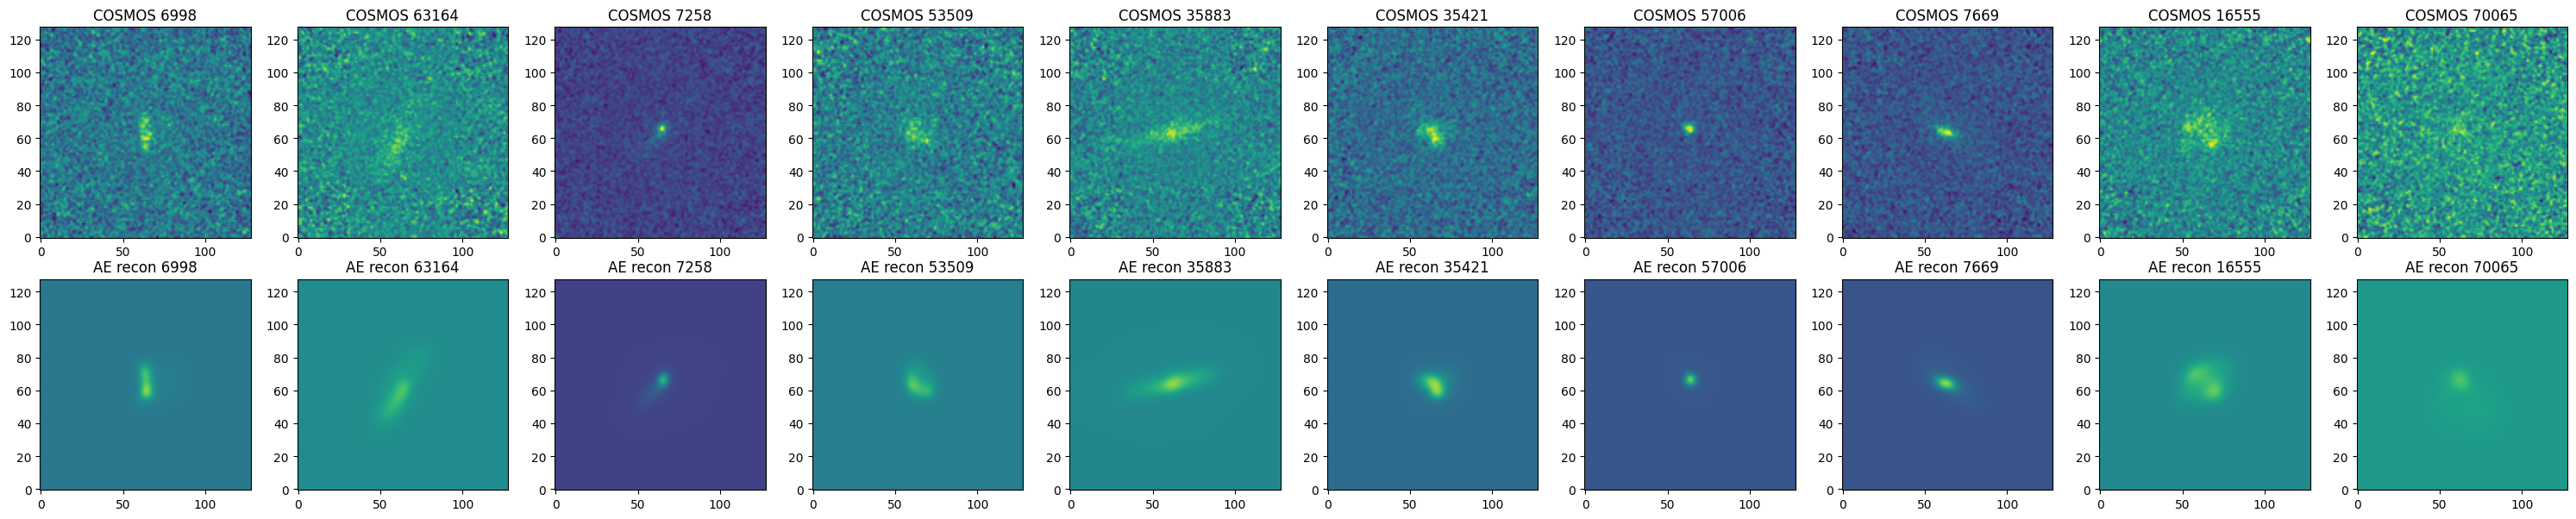

In [7]:
# Plot an example of the HST original galaxy vs the AE reconstruction
fig, axes = plt.subplots(2, Ngal, figsize=(3*Ngal, 6))
for i in range(Ngal):
    vmin = min(obs_np[i].min(), y_ae_np[i].min())
    vmax = max(obs_np[i].max(), y_ae_np[i].max())
    axes[0, i].imshow(obs_np[i], origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f'COSMOS {indices_ae[i]}')
    axes[1, i].imshow(y_ae_np[i], origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, i].set_title(f'AE recon {indices_ae[i]}')
plt.tight_layout()

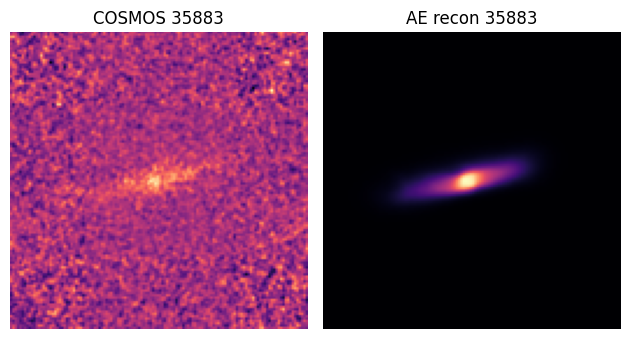

In [9]:
# Plot a single example side by side
i = 4
vmin = min(obs_np[i].min(), g_ae_np[i].min())
vmax = max(obs_np[i].max(), g_ae_np[i].max())
plt.subplot(1, 2, 1)
plt.imshow(obs_np[i], origin='lower', cmap='magma')
plt.title(f'COSMOS {indices_ae[i]}')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(g_ae_np[i], origin='lower', cmap='magma')
plt.title(f'AE recon {indices_ae[i]}')
plt.axis('off')
plt.tight_layout()

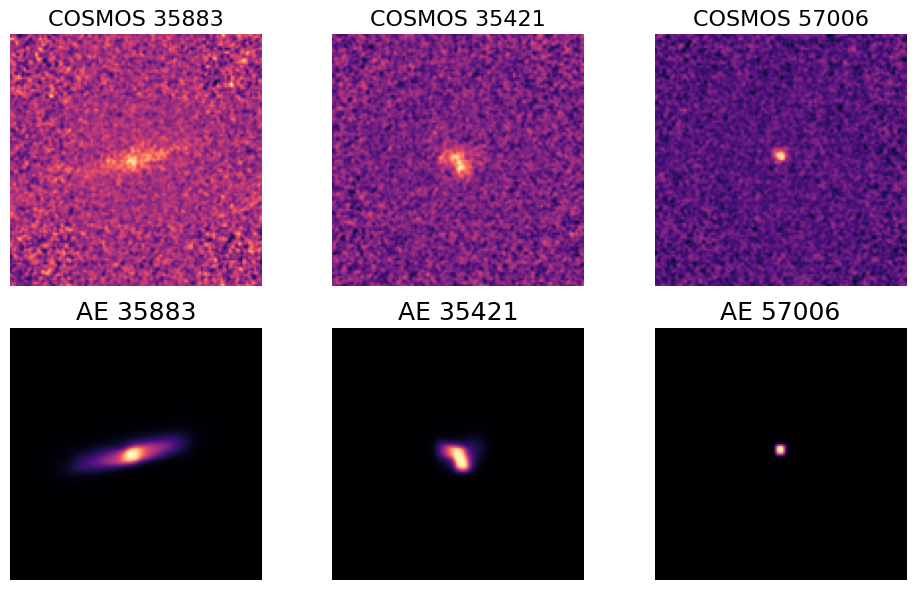

In [11]:
# 2x3 plot of reconstructed galaxies vs original COSMOS observations
ids = [4, 5, 6]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i, idx in enumerate(ids):
    vmin = min(obs_np[idx].min(), g_ae_np[idx].min())
    vmax = max(obs_np[idx].max(), g_ae_np[idx].max())
    axes[0, i].imshow(obs_np[idx], origin='lower', cmap='magma')
    axes[0, i].set_title(f'COSMOS {indices_ae[idx]}', fontsize=16)
    axes[0, i].axis('off')
    axes[1, i].imshow(g_ae_np[idx], origin='lower', cmap='magma')
    axes[1, i].set_title(f'AE {indices_ae[idx]}', fontsize=18)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("../figs/ae_reconstructions.pdf")
plt.show()
